**Environment Setup**

In [ ]:
import numpy as np
from google.colab import drive
from matplotlib.lines import Line2D
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


**Necessary Parameter Setup**

In [ ]:
max_warmup = 1000
warmup_window = 100

window_array = np.append(np.repeat(10, 10),
                      np.repeat(warmup_window, max_warmup // warmup_window - 1))

warmup_length = np.repeat(10, len(window_array))
for i in range(len(warmup_length) - 1):
    warmup_length[i + 1] = warmup_length[i] + window_array[i + 1]

# Transition kernel for short regime
repitition = 10
num_chains_short = 2048
num_super_chains = 16

In [ ]:
# quantiles for chi squared with df = 1
chi_up = 3.841459 # 95th quantile for chi squared with df = 1
chi_lo = 0.00393214  # 05th quantile for chi squared with df = 1
tau = 1e-4
M = num_chains_short // num_super_chains
nRhat_lower = np.sqrt(1 + 1 / M + tau)
eps_lower = nRhat_lower - 1
bound = [chi_lo / num_chains_short, chi_up / num_chains_short]
threshold = eps_lower

In [ ]:
# utility_link = '/content/drive/MyDrive/JHU Stuff/Capstone/Utility_Functions/Plot_Utility.py'
# with open(utility_link) as f: exec(f.read())

In [ ]:
############################################
# Paper Replication
############################################
# Line Plots
def MSE_vs_Warmup(W_c_df, W_n_df,title):
    fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
    common = dict(
        logx=True,logy=True,
        legend=False,ax=ax,
        ylabel="Mean Sqaured Error",
        x="Warmup Length",fontsize=14)
    ax = W_c_df.plot(
        y="Avg MSE",title=title,
        linestyle="-",color="orange",**common)
    W_c_df.plot(
        y="Best MSE",linestyle="--",
        color="orange",**common)
    W_c_df.plot(
        y="Worst MSE",linestyle="--",
        color="orange",**common)
    W_n_df.plot(
        y="Avg MSE",linestyle="-",
        color="black",**common)
    W_n_df.plot(
        y="Worst MSE",linestyle="--",
        color="black",**common)
    W_n_df.plot(
        y="Best MSE",linestyle="--",
        color="black",**common)
    ax.set_title(title, fontsize=18, fontweight="bold", pad=12)
    ax.set_xlabel(common["x"], fontsize=common["fontsize"])
    ax.set_ylabel(common["ylabel"], fontsize=common["fontsize"])
    ax.legend(handles=[
        Line2D([0], [0], color="orange", lw=2, label="Constrained"),
        Line2D([0], [0], color="black", lw=2, label="Naive")])

# Scatter Plots
def MSE_vs_Rhat(df, title, naive, bound, threshold, num_subchains):
    fig, ax = plt.subplots(figsize=(10, 8), dpi=150)

    ax.scatter(
        df["Rhat"] - 1,
        df["MSE"],
        color="blue",
        s=35,
        alpha=0.4,
    )

    ax.set_yscale("log")
    if not naive:
        ax.set_xscale("log")

    ax.axhline(bound[0], color="black", linestyle="--")
    ax.axhline(bound[1], color="black", linestyle="--")
    ax.axhline(1 / num_subchains, color="black")
    ax.axvline(threshold, color="blue", linestyle="--")
    ax.tick_params(axis='both', labelsize=14)

    ax.set_xlabel(r"$\widehat{R}_{\nu}-1$",fontsize=14)
    ax.set_ylabel("Scaled squared error",fontsize=14)

    suffix = "Constrained" if not naive else "Naive"
    ax.set_title(f"{title} - {suffix}", fontsize=20, fontweight="bold")

    plt.tight_layout()
    plt.show()

############################################
# Enhanced Plotting Functions
############################################
def MSE_vs_Warmup_Jumbo(tfp_c_df, tfp_n_df,
                        bjx_c_df, bjx_n_df,
                        pf_df, title):
    fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
    colors = {
           "TFP":"orange",
           "BlackJAX":"black",
           "PathFinder":"blue"}
    linestyles = {
           "Constrained":"-",
           "Naive":"--"}

    def plot_with_band(df, color, linestyle, label, hatch):
        ax.plot(df["Warmup Length"],df["Avg MSE"],
                color = color,linestyle = linestyle,
                linewidth = 2,label = label)
        ax.fill_between(df["Warmup Length"],df["Best MSE"],
                        df["Worst MSE"],color = color,
                        alpha = 0.20,hatch = hatch)
    # TFP implementation:
    plot_with_band(
        tfp_c_df,colors["TFP"],
        linestyles["Constrained"],"TFP-Constrained",
        hatch = None)
    plot_with_band(
        tfp_n_df,colors["TFP"],
        linestyles["Naive"],"TFP-Naive",
        hatch = "oo")
    # BlackJAX implementation
    plot_with_band(
        bjx_c_df,colors["BlackJAX"],
        linestyles["Constrained"],"BlackJAX-Constrained",
        hatch = None)
    plot_with_band(
        bjx_n_df,colors["BlackJAX"],linestyles["Naive"],
        "BlackJAX-Naive",hatch = "xxx")
    plot_with_band(
        pf_df,colors["PathFinder"],'-',
        "PathFinder Initialization",hatch = None)

    ax.set_title(title, fontsize=20, fontweight="bold")
    ax.set_ylabel("Mean Squared Error",fontsize=14)
    ax.set_xlabel("Warmup Length",fontsize=14)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.tick_params(axis='both', labelsize=14)

    ax.legend()
    plt.show()

# Color Coded Scatter Plots
def MSE_vs_Rhat_color(dfs, titles, supertitle, bound,
                      threshold,num_subchains, color_choice):
    fig, axes = plt.subplots(2,3, figsize=(25,10),dpi=150,
                             sharex=True, sharey = True)
    axes = axes.flatten()
    if color_choice == "Dimension":
        vmin = min(df["Dimension"].min() for df in dfs)
        vmax = max(df["Dimension"].max() for df in dfs)

        for ax, df, panel_title in zip(axes, dfs, titles):
            sc = ax.scatter(
                df["Rhat"] - 1,
                df["MSE"],
                c = df["Dimension"],
                cmap = "viridis",
                vmin = vmin,
                vmax = vmax,
                s=35,
                alpha = 0.5)

            ax.set_title(panel_title, fontsize=15, pad=8)
        cbar = fig.colorbar(sc, ax = axes, shrink=0.8,fraction =0.025,pad=0.02,)
        cbar.set_label("Dimension")

        if vmax - vmin <= 20:
            tick_values = np.arange(vmin, vmax +1)
        else:
            tick_values = np.linspace(vmin , vmax, 5). round().astype(int)
        cbar.set_ticks(tick_values)

    elif color_choice== "Warmup Length":
        warmups = np.sort(
            np.unique(np.concatenate(
                [df["Warmup Length"].unique() for df in dfs]
                )))
        cmap = plt.get_cmap("RdYlBu_r")
        color_map = {
            w:cmap(x)
            for w, x in zip(warmups, np.linspace(0,1,len(warmups)))}

        for ax, df, panel_title in zip(axes, dfs, titles):
            groups = df.groupby("Warmup Length")

            for warmup, subset in groups:
                ax.scatter(
                    subset["Rhat"] -1,
                    subset["MSE"],
                    color = color_map[warmup],
                    s=35,
                    alpha=0.5)
            ax.set_title(panel_title, fontsize=15, pad=8)
        handles = [
            Line2D([0],[0],marker="o", color = color_map[warmup],
            linestyle = "", markersize = 7, label=str(warmup)) for warmup in warmups]

        fig.legend(
            handles = handles,
            title = "Warmup Length",
            loc = "center left",
            bbox_to_anchor = (0.84, 0.5),
            fontsize = 9)
    else:
        raise ValueError("color_choice must be either \"Dimension\" or \"Warmup Length\"!")

    for ax in axes:
        ax.set_yscale("log")
        ax.set_xscale("log")

        ax.axhline(
            bound[0], color="black",linestyle="--")
        ax.axhline(
            bound[1], color="black",linestyle="--")
        ax.axhline(
            1 / num_subchains,color="black")
        ax.axvline(
            threshold, color="blue",linestyle="--")

        ax.set_xlabel(r"$\widehat{R}_{\nu}-1$",fontsize=14)
        ax.set_ylabel("Scaled Squared Error",fontsize=14)
        ax.tick_params(
            axis="both",which = "both",
            labelbottom = True,labelleft = True,
            labelsize=14)
    fig.subplots_adjust(top=0.88,bottom=0.08,left=0.07,
                        right=0.82,hspace=0.32,wspace=0.20)
    fig.suptitle(supertitle, fontsize=20, fontweight="bold")
    plt.show()

**Isotropic Covariance**

In [ ]:
##########################
# BlackJAX implementation:
##########################
# MSE vs Warmups:
Iso_MSE_c_path = '/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/DimensionExperiment/Iso_MSE_c.pkl'
Iso_MSE_c_df = pd.read_pickle(Iso_MSE_c_path)

Iso_MSE_n_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/DimensionExperiment/Iso_MSE_n.pkl"
Iso_MSE_n_df = pd.read_pickle(Iso_MSE_n_path)

# MSE vs nested Rhat:
Iso_R_hat_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/DimensionExperiment/Iso_Rhat_c.pkl"
Iso_R_Hat_c_df = pd.read_pickle(Iso_R_hat_c_path)

Iso_R_hat_n_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/DimensionExperiment/Iso_Rhat_n.pkl"
Iso_R_Hat_n_df = pd.read_pickle(Iso_R_hat_n_path)
print("Isotropic covariance data Loaded!")

Isotropic covariance data Loaded!


In [ ]:
Iso_MSE_c_10 = Iso_MSE_c_df[Iso_MSE_c_df["Size"] == 10]
Iso_MSE_c_20 = Iso_MSE_c_df[Iso_MSE_c_df["Size"] == 20]
Iso_MSE_c_50 = Iso_MSE_c_df[Iso_MSE_c_df["Size"] == 50]
Iso_MSE_c_100 = Iso_MSE_c_df[Iso_MSE_c_df["Size"] == 100]

Iso_MSE_n_10 = Iso_MSE_n_df[Iso_MSE_n_df["Size"] == 10]
Iso_MSE_n_20 = Iso_MSE_n_df[Iso_MSE_n_df["Size"] == 20]
Iso_MSE_n_50 = Iso_MSE_n_df[Iso_MSE_n_df["Size"] == 50]
Iso_MSE_n_100 = Iso_MSE_n_df[Iso_MSE_n_df["Size"] == 100]

In [ ]:
Iso_R_Hat_c_10 = Iso_R_Hat_c_df[Iso_R_Hat_c_df["Size"] == 10]
Iso_R_Hat_c_20 = Iso_R_Hat_c_df[Iso_R_Hat_c_df["Size"] == 20]
Iso_R_Hat_c_50 = Iso_R_Hat_c_df[Iso_R_Hat_c_df["Size"] == 50]
Iso_R_Hat_c_100 = Iso_R_Hat_c_df[Iso_R_Hat_c_df["Size"] == 100]

Iso_R_Hat_n_10 = Iso_R_Hat_n_df[Iso_R_Hat_n_df["Size"] == 10]
Iso_R_Hat_n_20 = Iso_R_Hat_n_df[Iso_R_Hat_n_df["Size"] == 20]
Iso_R_Hat_n_50 = Iso_R_Hat_n_df[Iso_R_Hat_n_df["Size"] == 50]
Iso_R_Hat_n_100 = Iso_R_Hat_n_df[Iso_R_Hat_n_df["Size"] == 100]

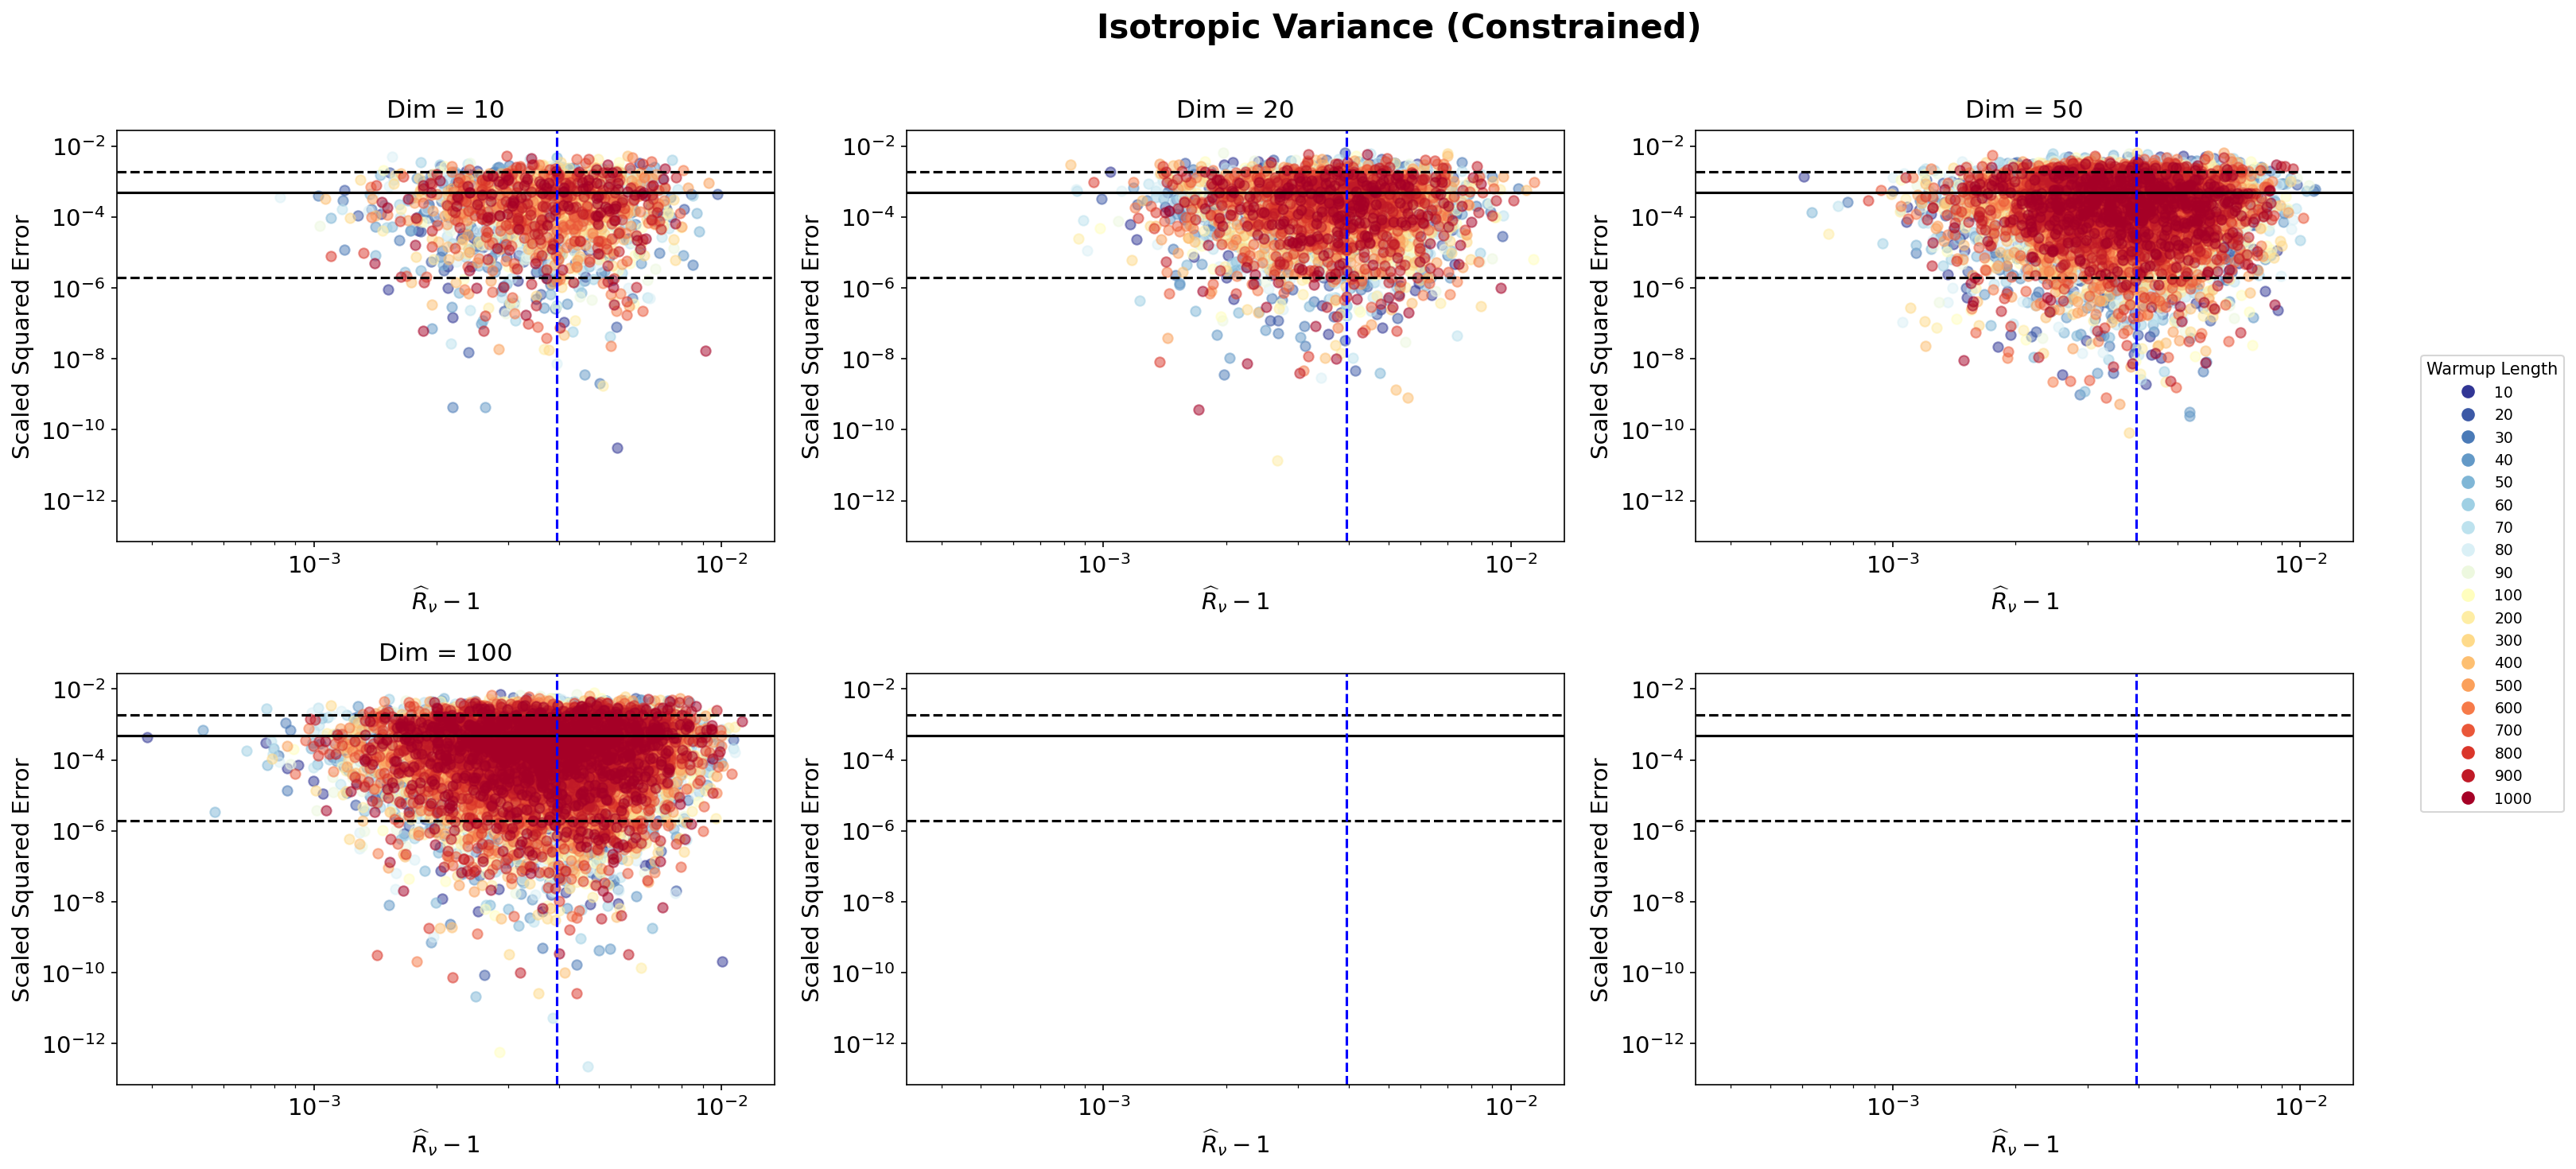

In [ ]:
dfs=[Iso_R_Hat_c_10, Iso_R_Hat_c_20, Iso_R_Hat_c_50,Iso_R_Hat_c_100]
titles =["Dim = 10","Dim = 20","Dim = 50", "Dim = 100"]
MSE_vs_Rhat_color(dfs, titles,"Isotropic Covariance (Constrained)",bound, threshold,num_chains_short,"Warmup Length")

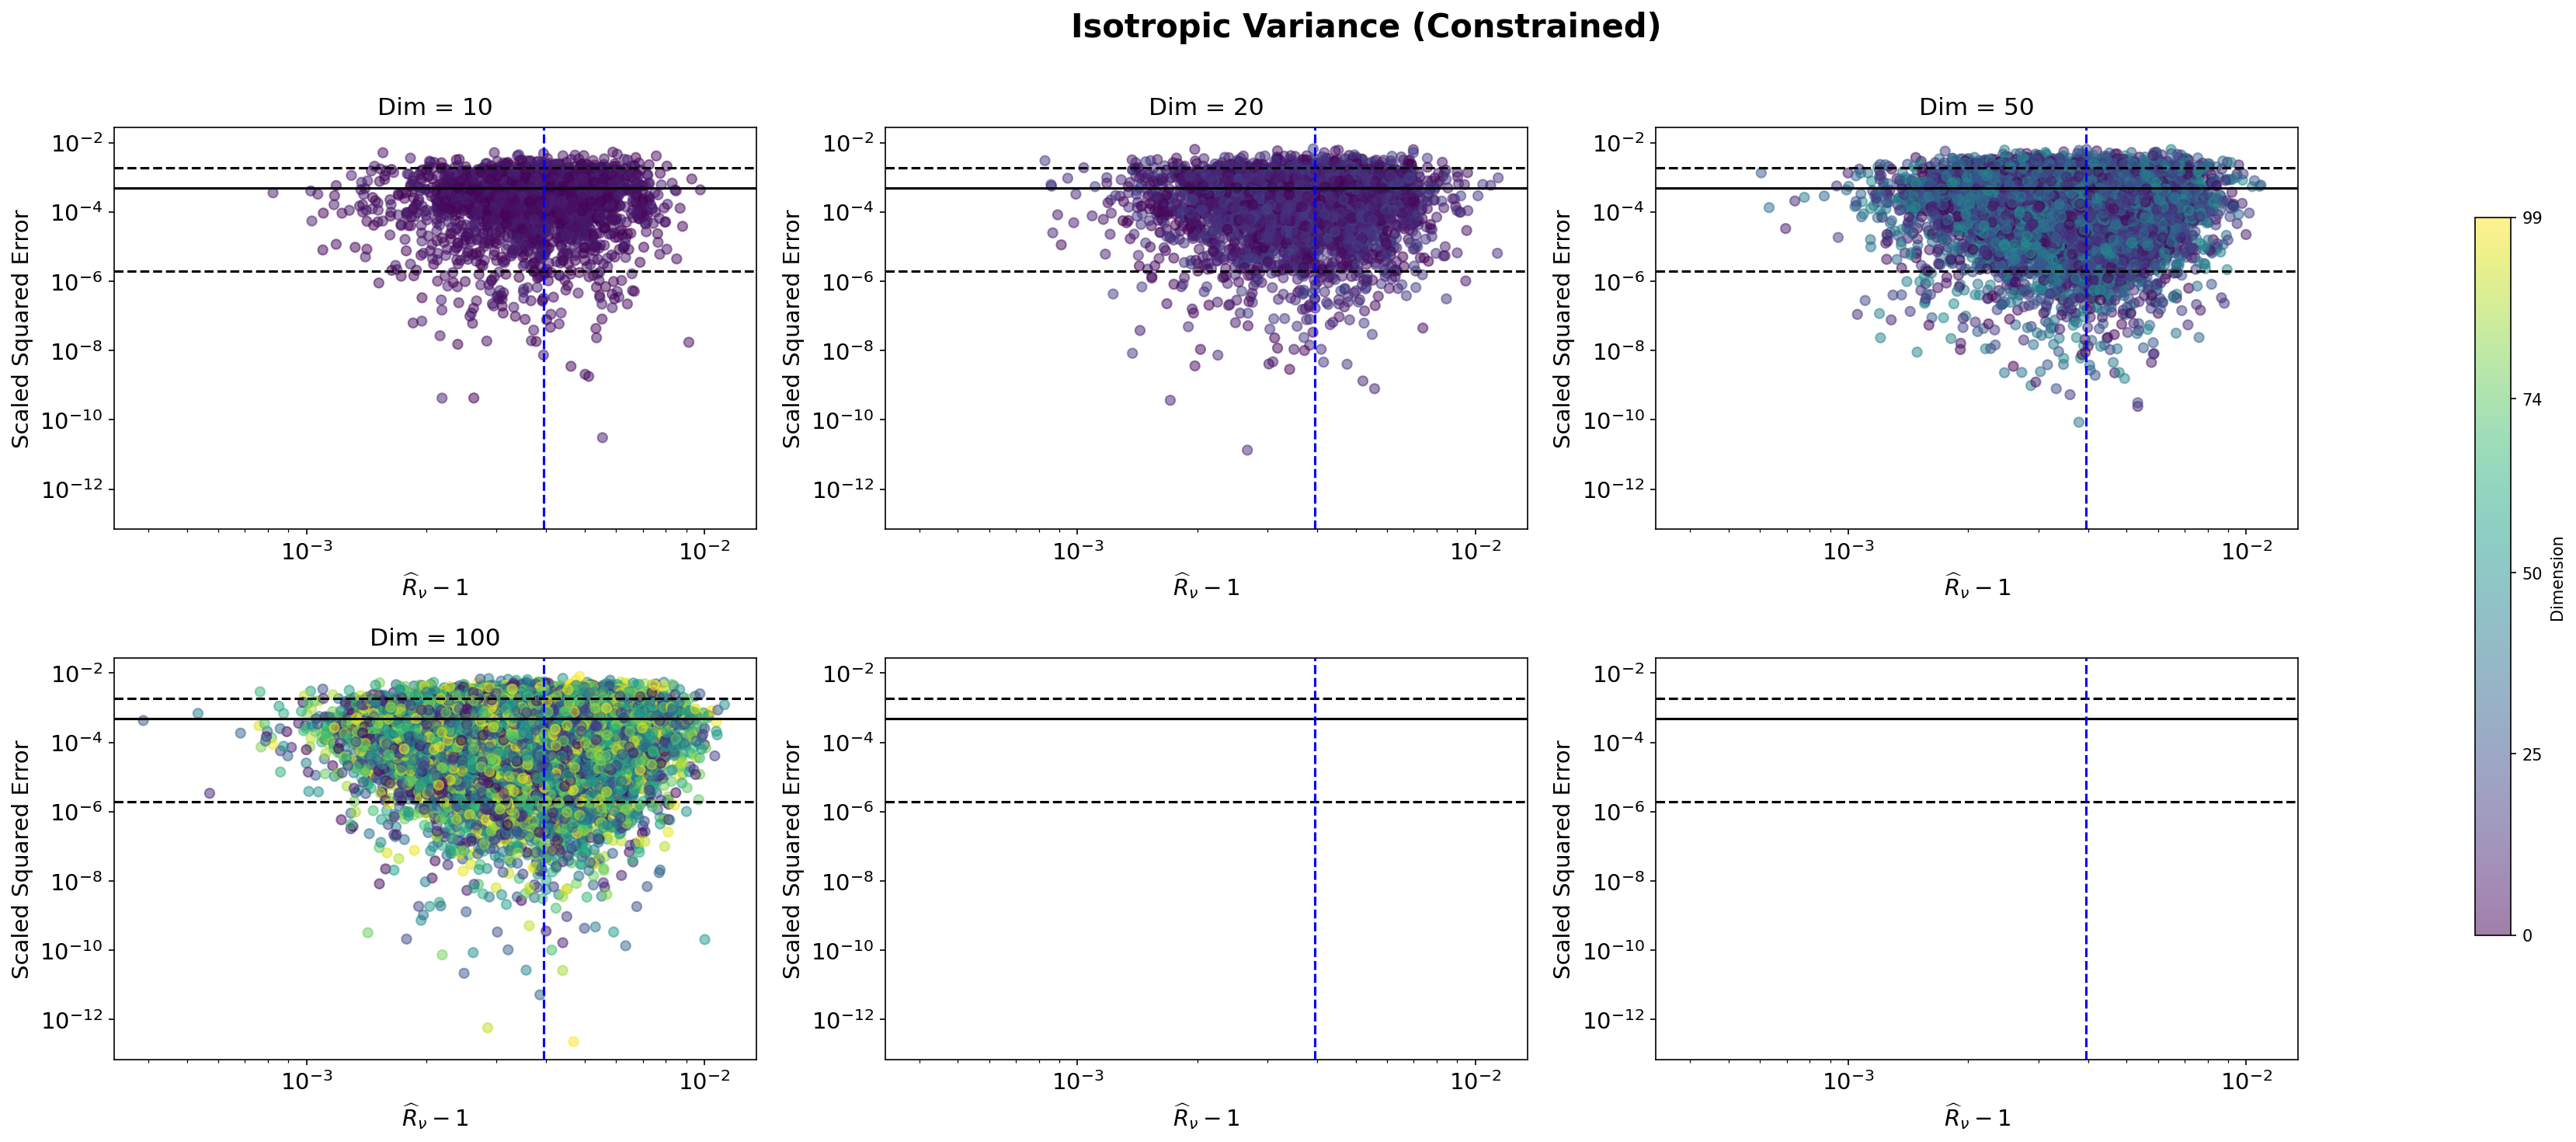

In [ ]:
MSE_vs_Rhat_color(dfs, titles,"Isotropic Covariance (Constrained)",bound, threshold,num_chains_short,"Dimension")

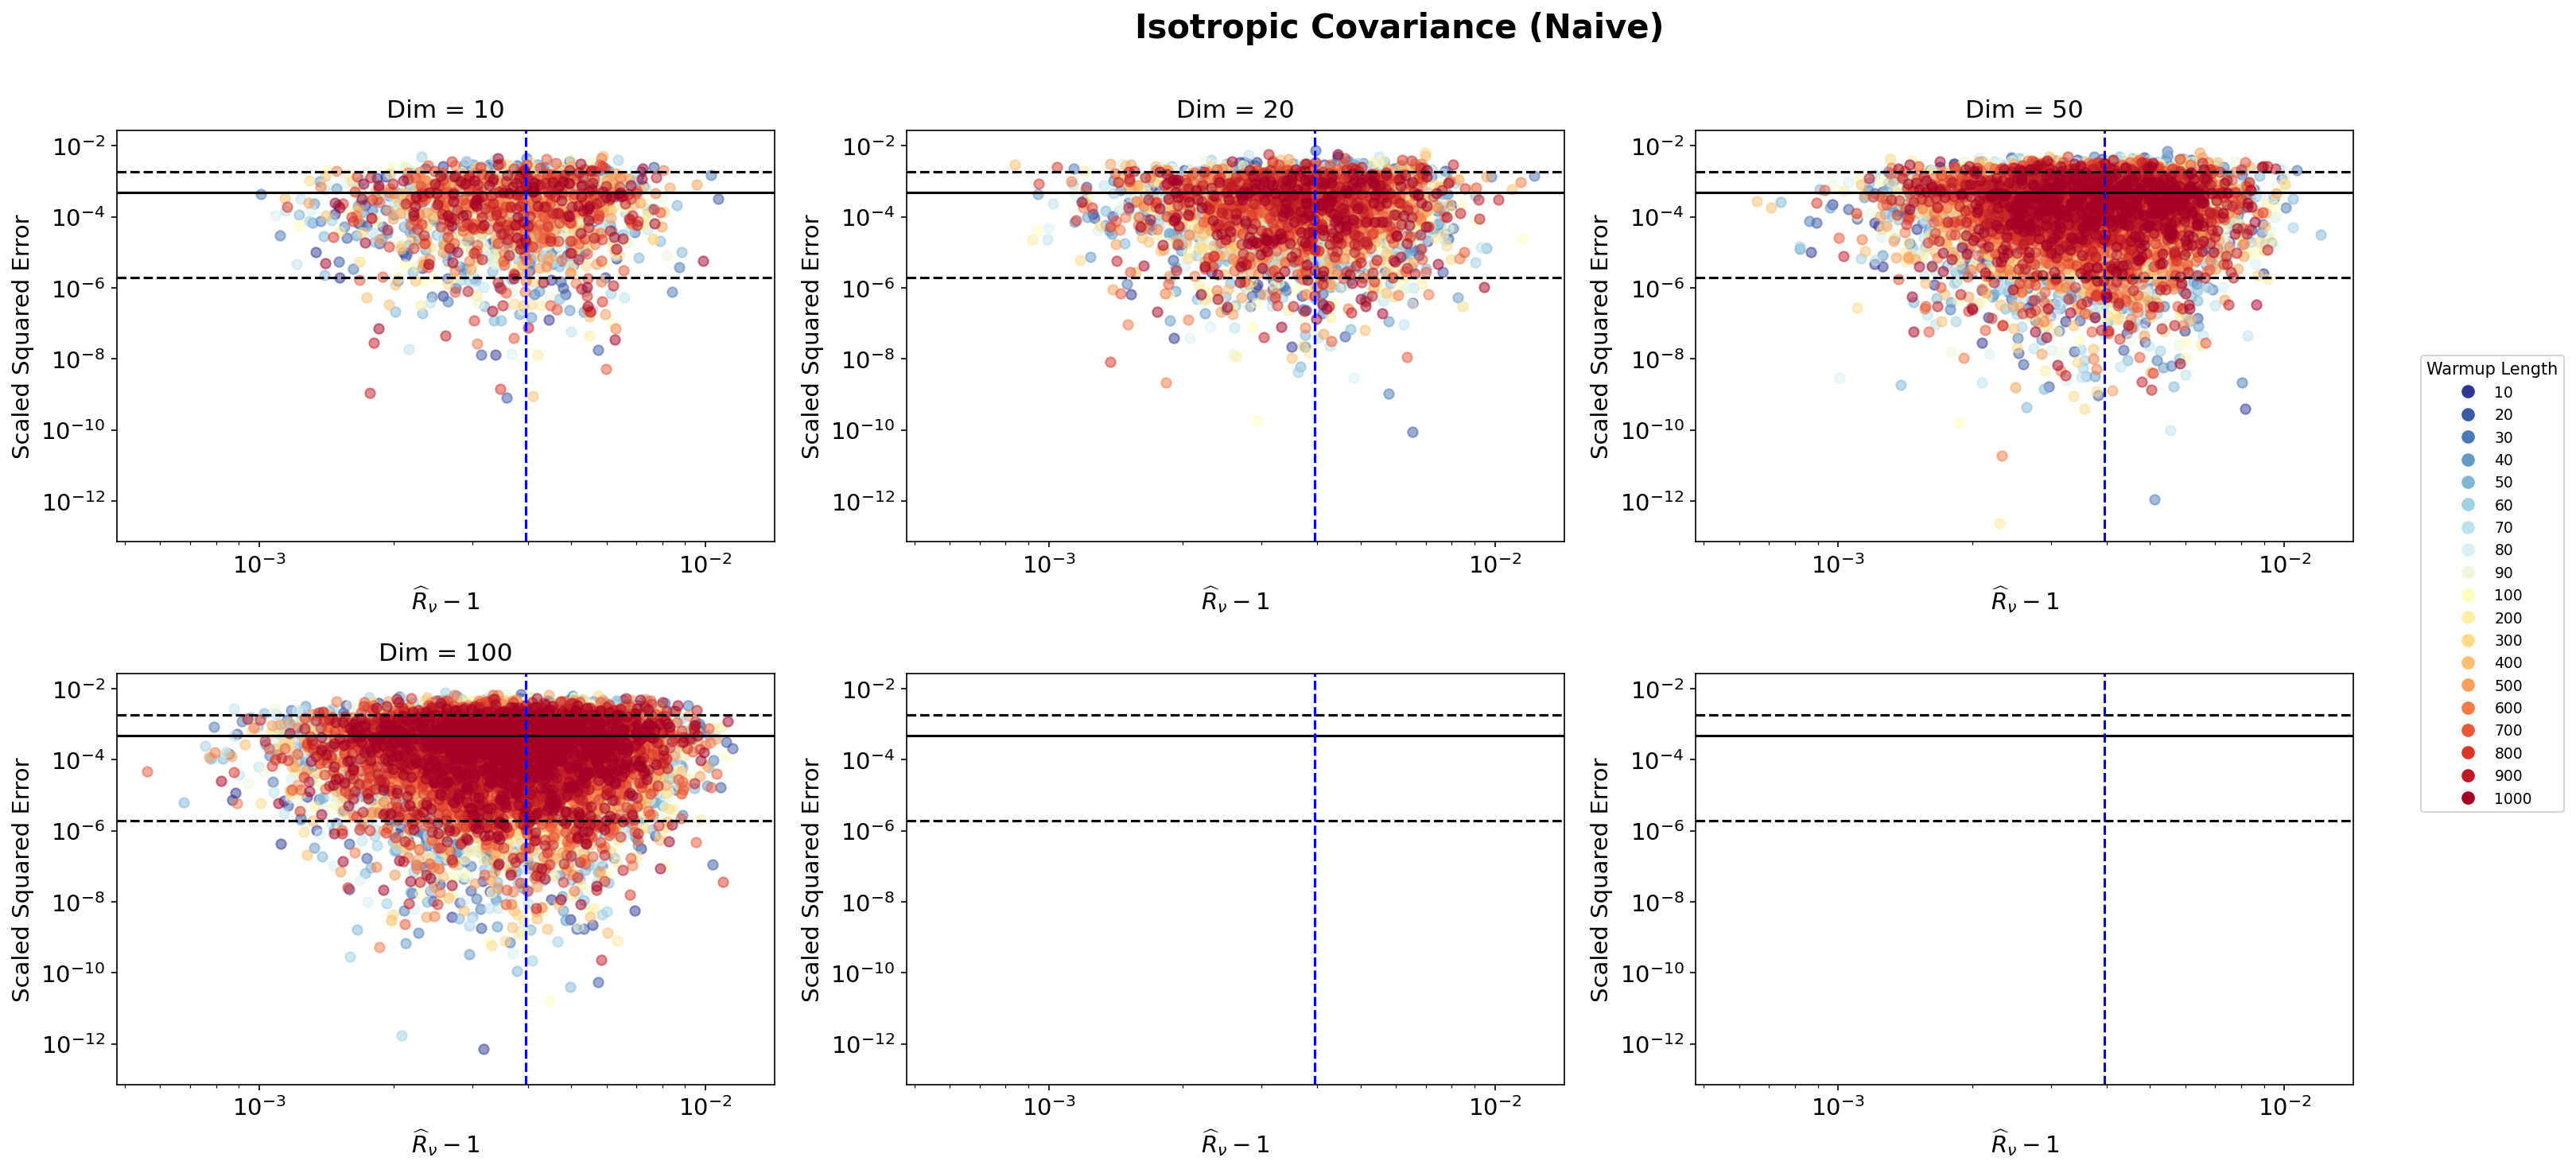

In [ ]:
dfs=[Iso_R_Hat_n_10, Iso_R_Hat_n_20, Iso_R_Hat_n_50,Iso_R_Hat_n_100]
titles =["Dim = 10","Dim = 20","Dim = 50", "Dim = 100"]
MSE_vs_Rhat_color(dfs, titles,"Isotropic Covariance (Naive)",bound, threshold,num_chains_short,"Warmup Length")

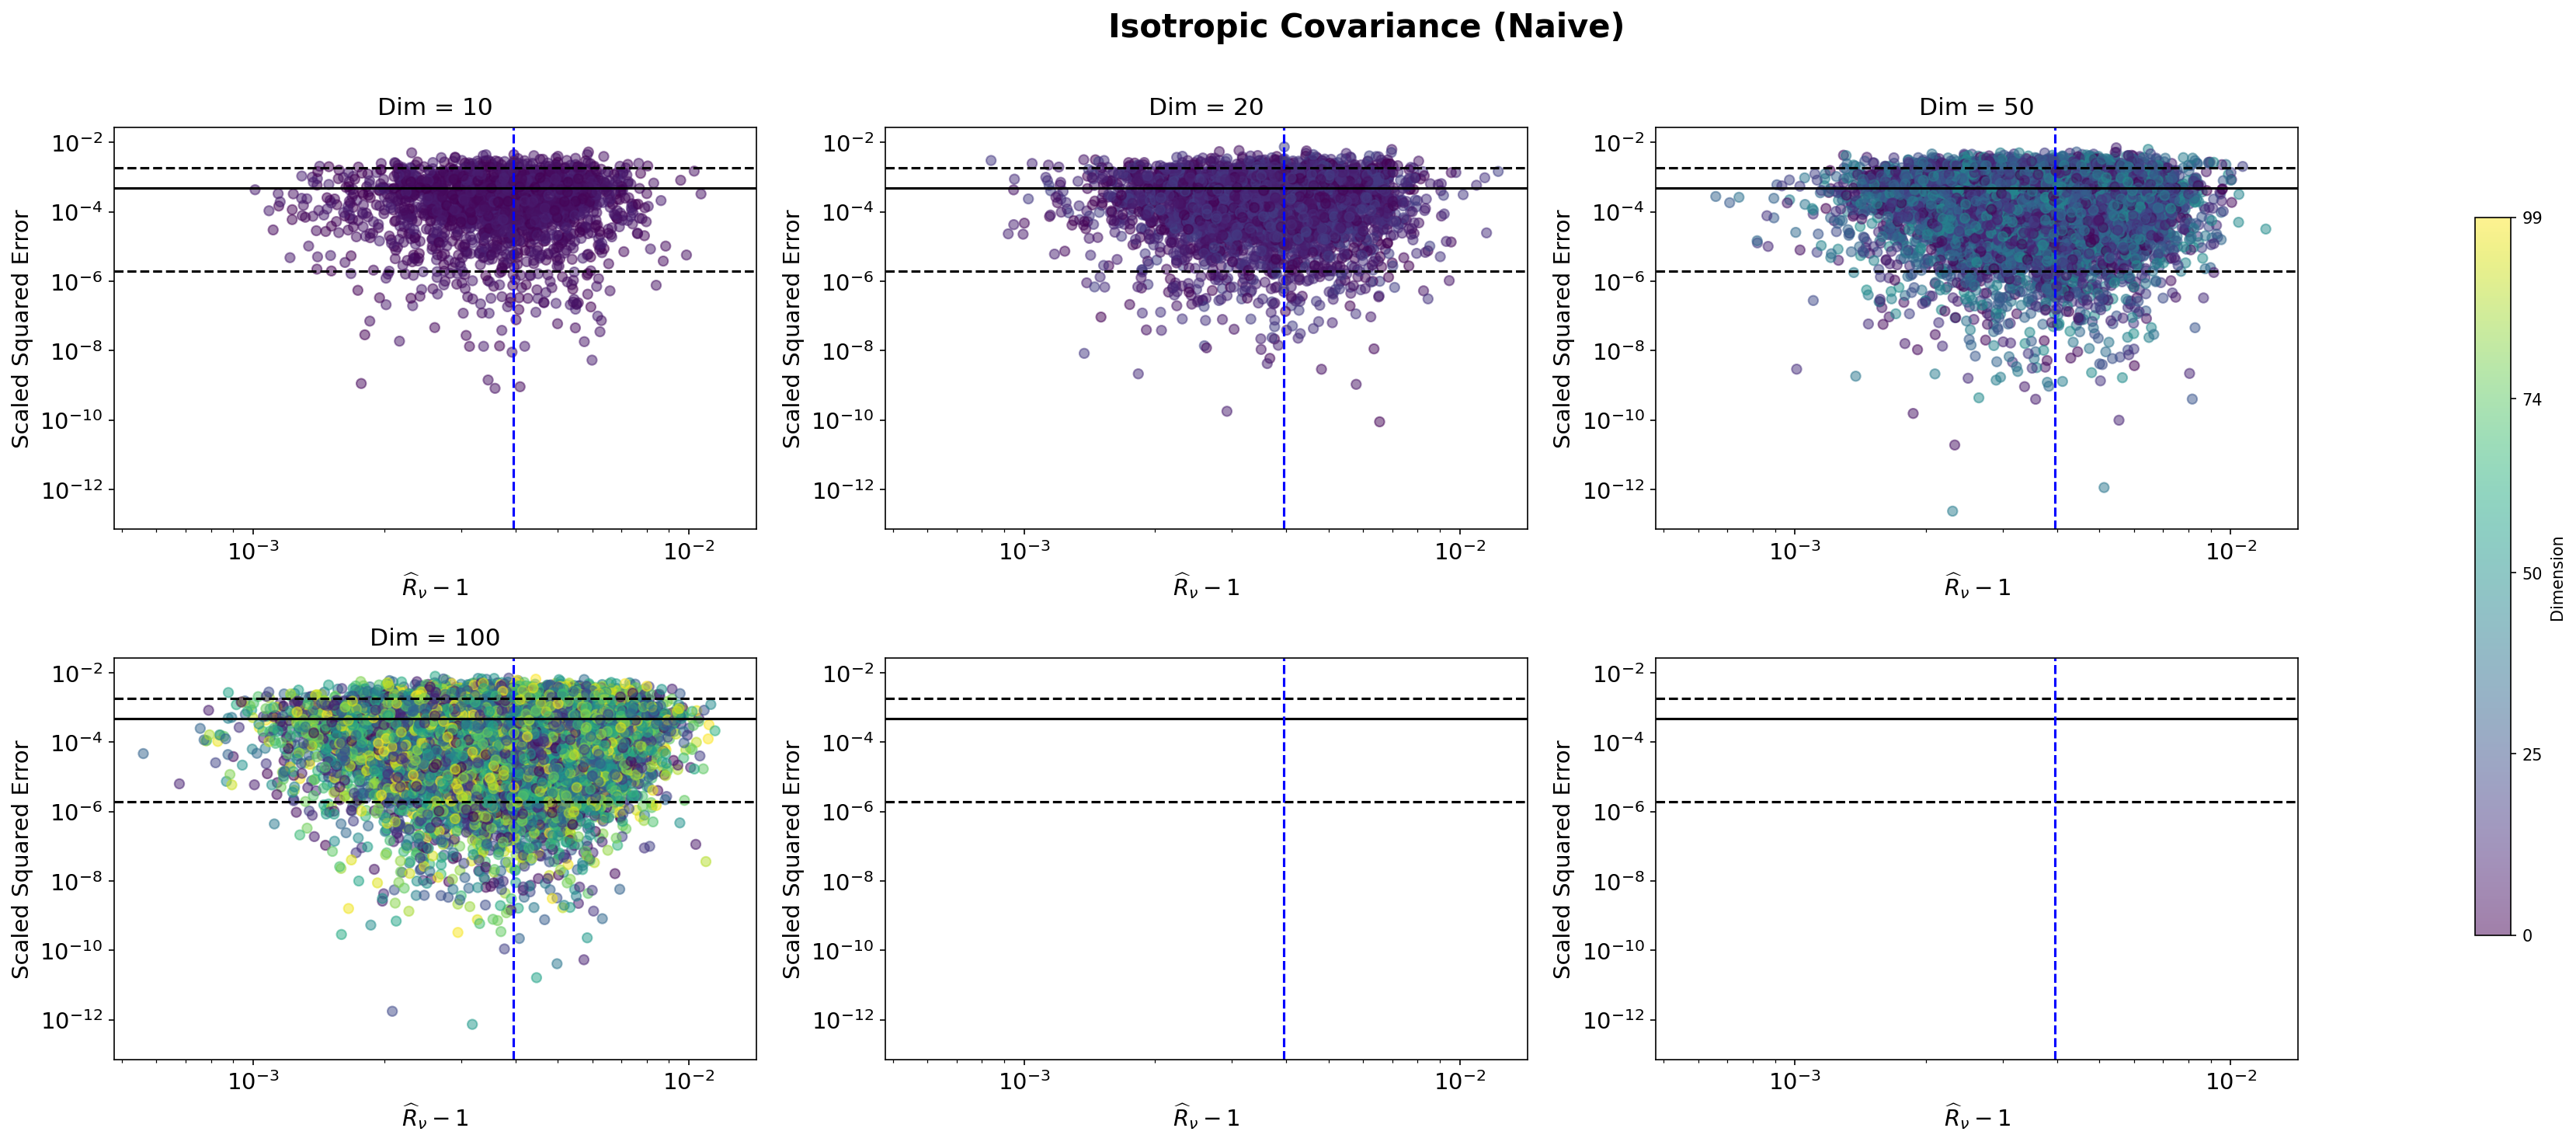

In [ ]:
MSE_vs_Rhat_color(dfs, titles,"Isotropic Covariance (Naive)",bound, threshold,num_chains_short,"Dimension")

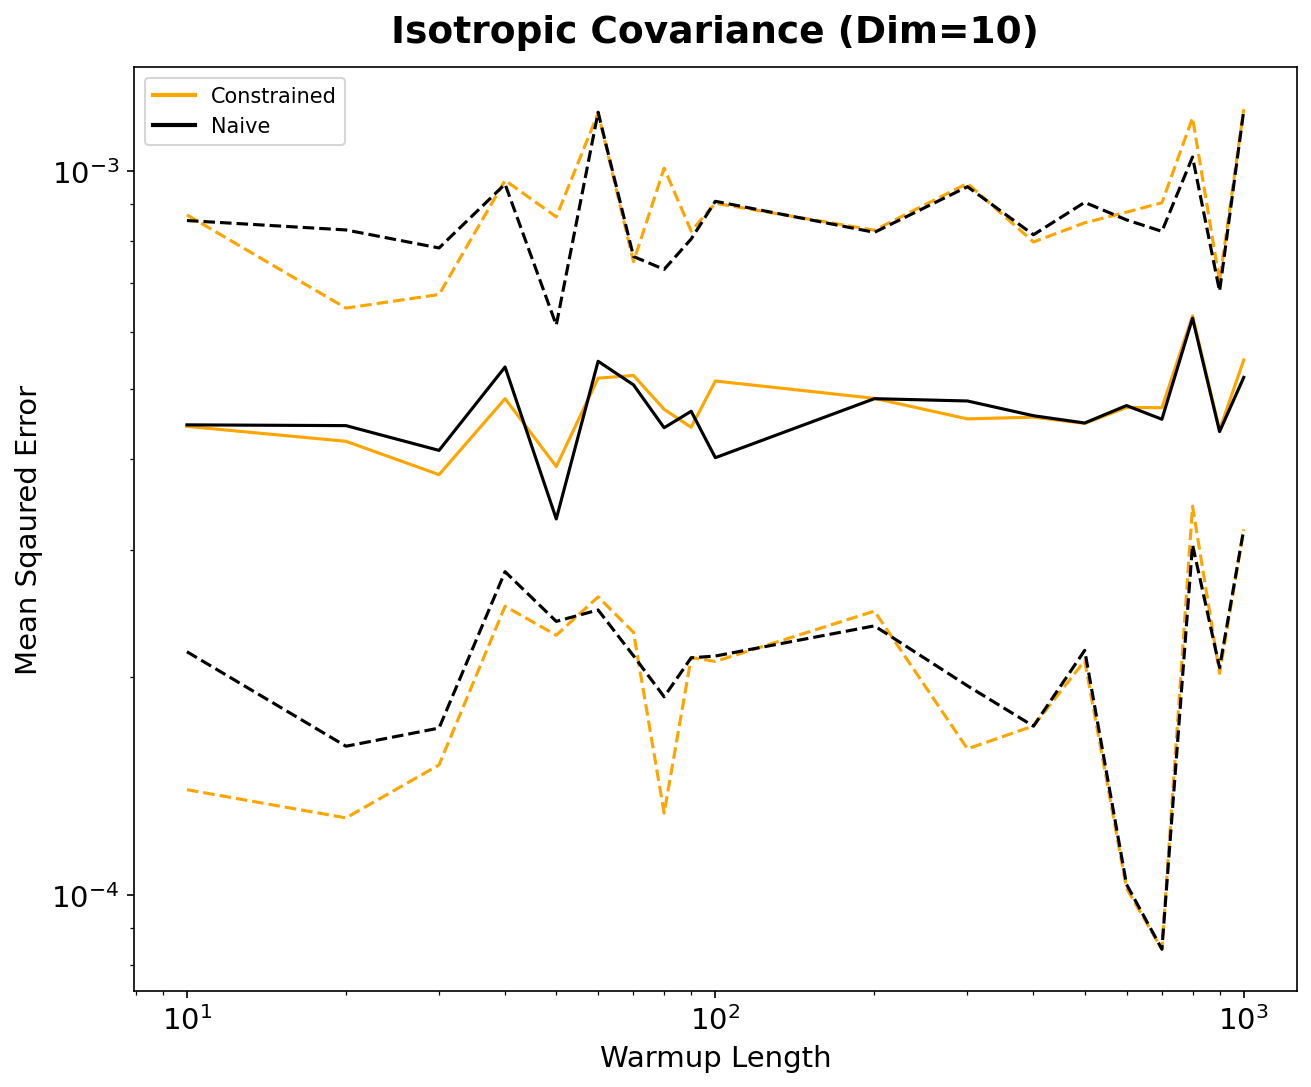

In [ ]:
MSE_vs_Warmup(Iso_MSE_c_10, Iso_MSE_n_10, "Isotropic Covariance (Dim=10)")

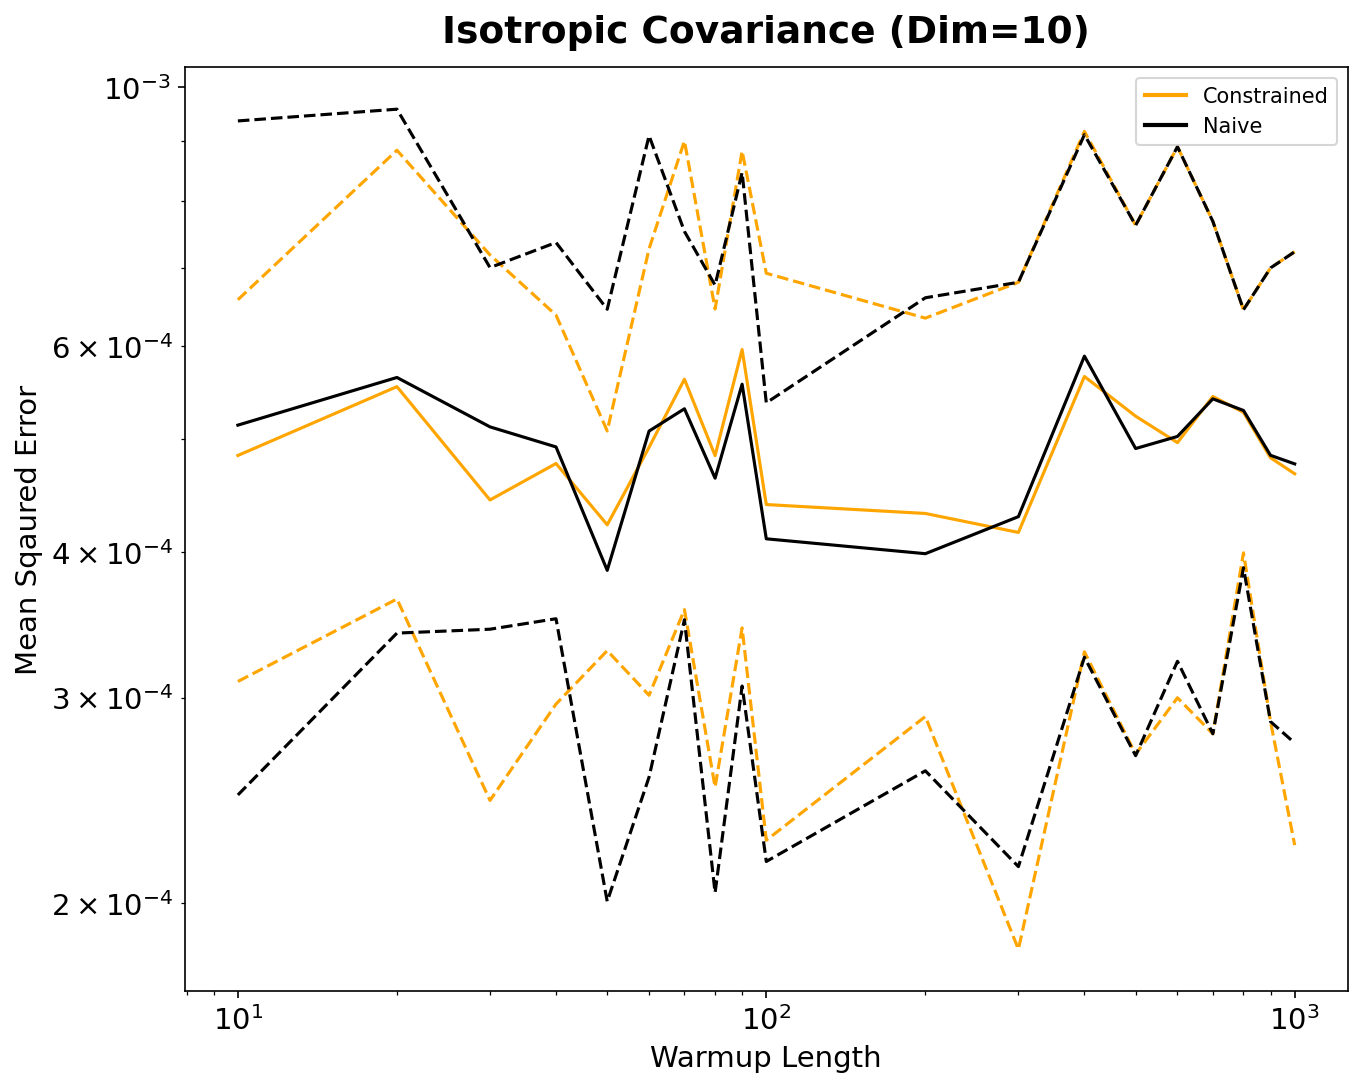

In [ ]:
MSE_vs_Warmup(Iso_MSE_c_20, Iso_MSE_n_20, "Isotropic Covariance (Dim=20)")

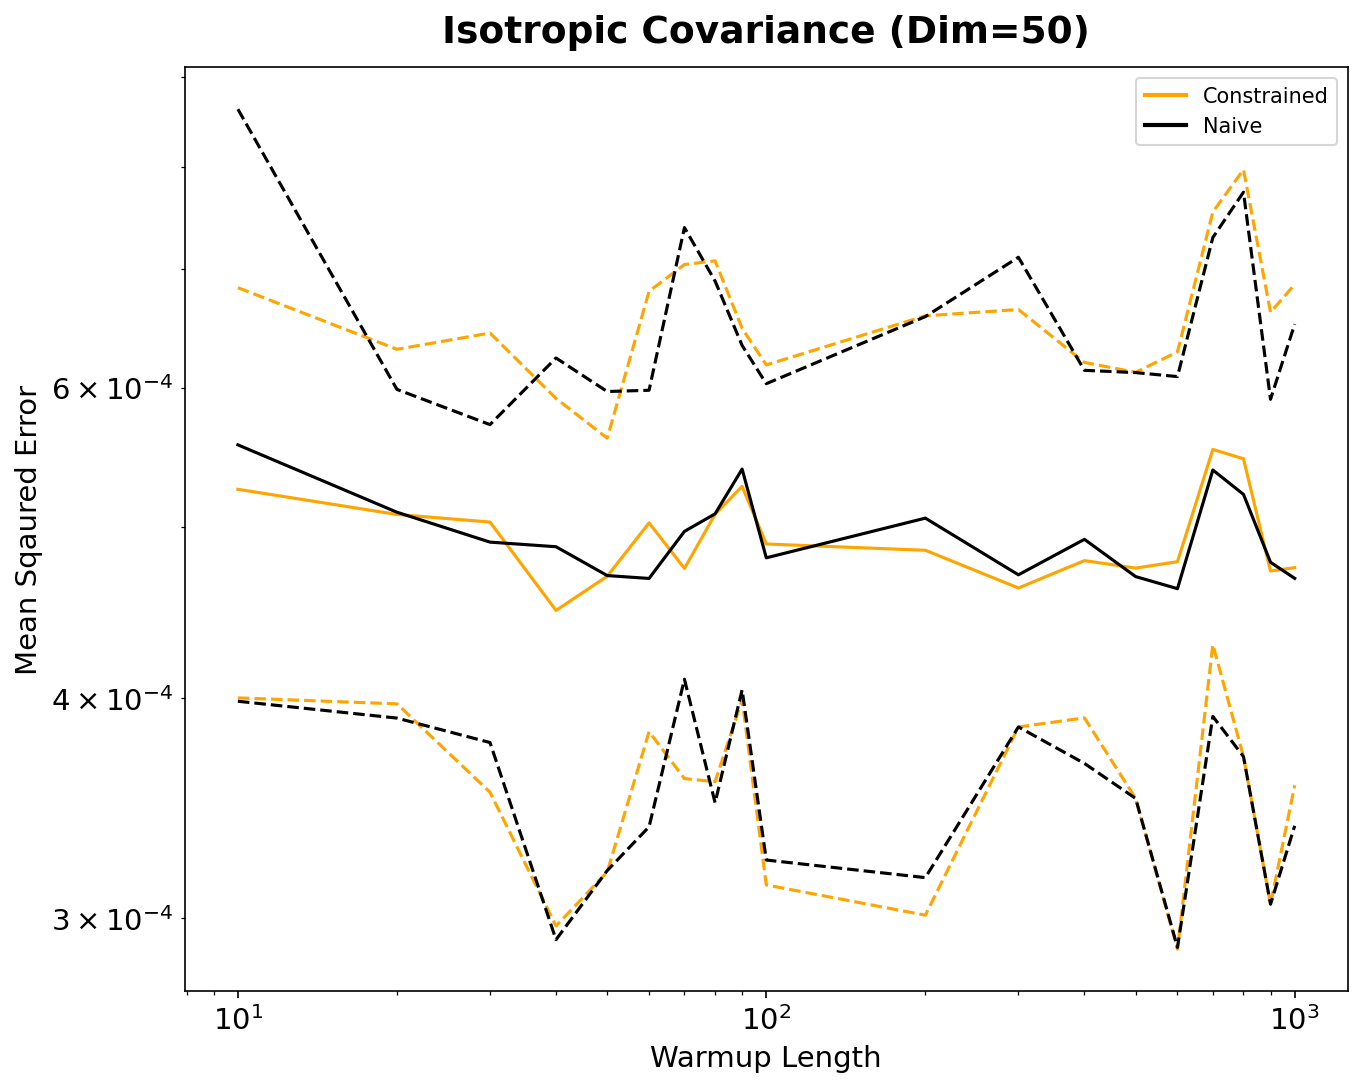

In [ ]:
MSE_vs_Warmup(Iso_MSE_c_50, Iso_MSE_n_50, "Isotropic Covariance (Dim=50)")

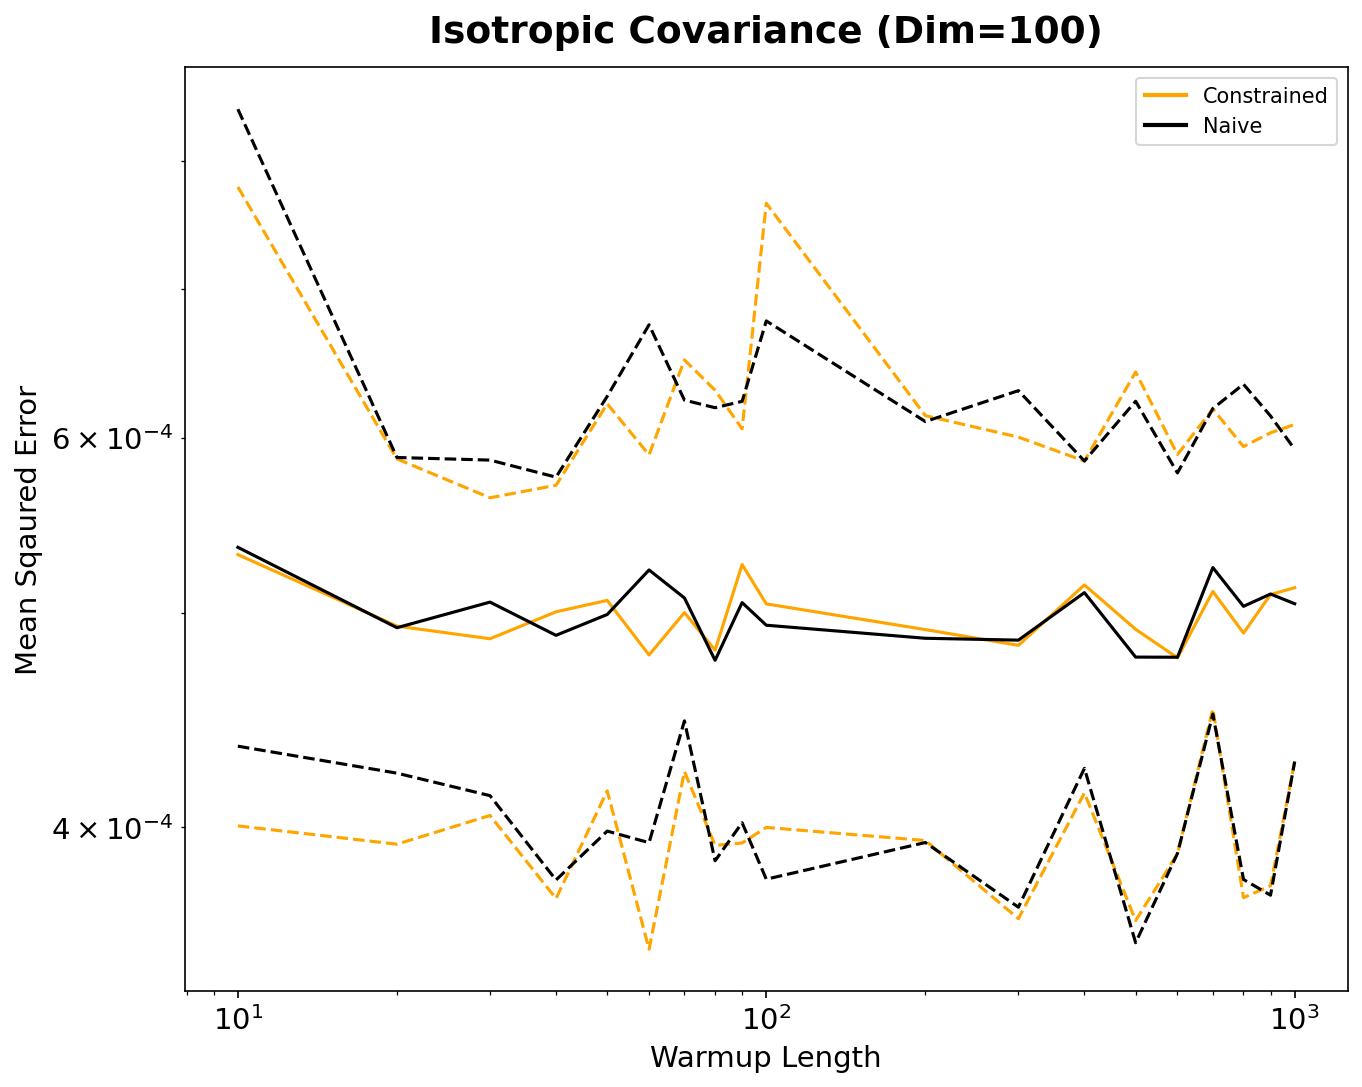

In [ ]:
MSE_vs_Warmup(Iso_MSE_c_100, Iso_MSE_n_100, "Isotropic Covariance (Dim=100)")